In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.style
import matplotlib as mpl
from cycler import cycler
import numpy as np

In [4]:
# === Global color palette ===
PALETTE = ['#007191', '#f47a00', '#62c8d3', '#c31e23', '#ff5a5e', '#fbac2b']

mpl.rcParams['axes.prop_cycle'] = cycler(color=PALETTE)
sns.set_palette(PALETTE)


In [5]:
phase1 = pd.read_csv("../results/phase_1.csv")
phase2 = pd.read_csv("../results/phase_2.csv")
phase3 = pd.read_csv("../results/phase_3.csv")
phase4 = pd.read_csv("../results/phase_4.csv")
phase5 = pd.read_csv("../results/phase_5.csv")

# === Fixed color mapping (consistent across all plots) ===
METHOD_COLORS = {
    "DCD_L2_perm":  "#007191",  # dark teal
    "LinearSVC_L1": "#f47a00",  # orange
    "LinearSVC_L2": "#62c8d3",  # light teal
    "SVC_linear":   "#c31e23",  # dark red
    "DCD_L1_perm":  "#ff5a5e",  # pink
}

IMPL_COLORS = {"our implementation": "#007191", "sklearn": "#f47a00"}
PENALTY_COLORS = {"L1": "#007191", "L2": "#f47a00"}


## PHASE 1 - Methods comparison

In [6]:
phase1["method_type"] = np.where(
    phase1["method"].str.contains("dcd", case=False, na=False),
    "our implementation",
    "sklearn"
)

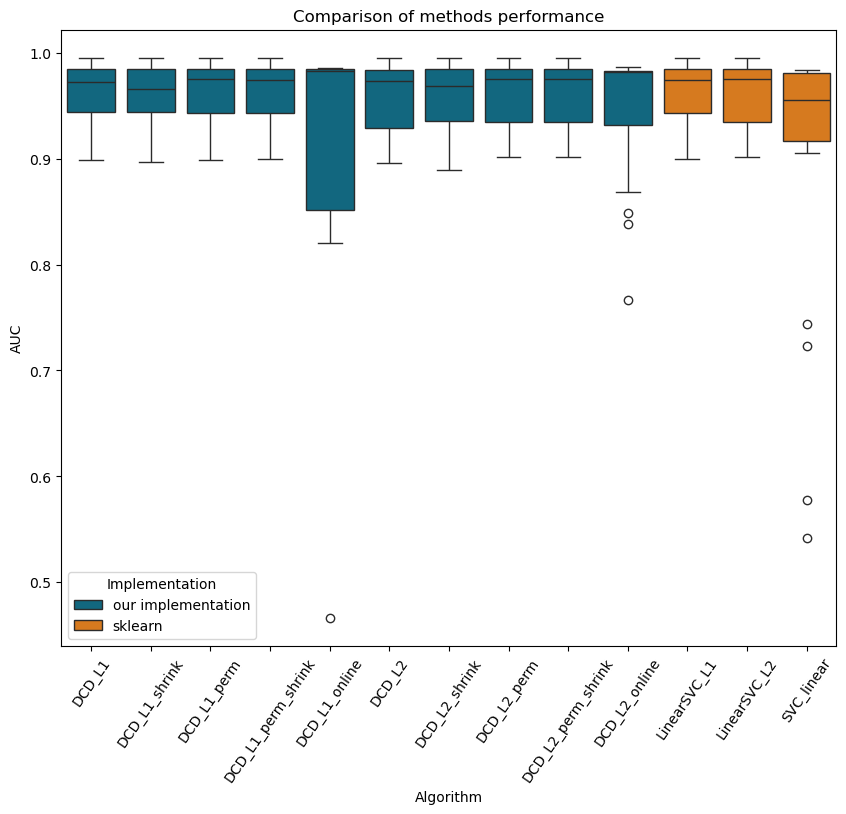

In [7]:
plt.figure(figsize=(10,8))
sns.boxplot(data=phase1, x="method", y="auc", hue="method_type", palette=IMPL_COLORS)
plt.xticks(rotation=55)
plt.legend(title="Implementation")
plt.xlabel("Algorithm")
plt.ylabel("AUC")
plt.title("Comparison of methods performance")
plt.show()


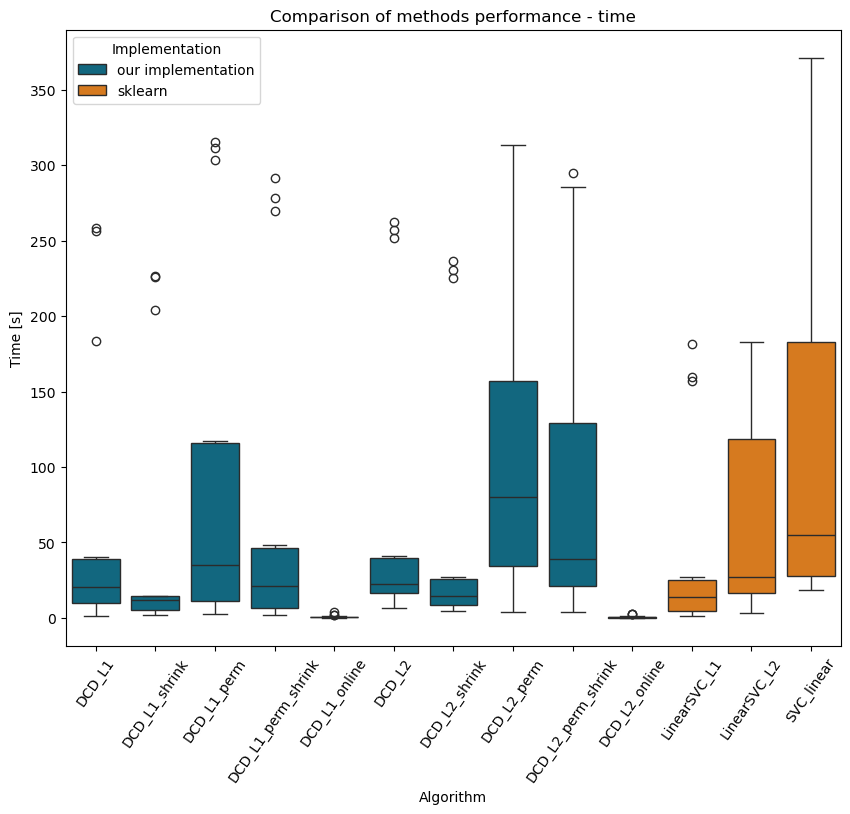

In [8]:
plt.figure(figsize=(10,8))
sns.boxplot(data=phase1, x="method", y="time_s", hue="method_type", palette=IMPL_COLORS)
plt.xticks(rotation=55)
plt.legend(title="Implementation")
plt.xlabel("Algorithm")
plt.ylabel("Time [s]")
plt.title("Comparison of methods performance - time")
plt.show()


In [9]:
phase1_own = phase1[phase1["method_type"] == "our implementation"]
phase1_own["method_type"] = np.where(
    phase1_own["method"].str.contains("L1", case=False, na=False),
    "L1",
    "L2"
)
phase1_own["method"] = phase1_own["method"].str.split("_").str[2:].str.join("_")
phase1_own["method"] = phase1_own["method"].replace("", "base")

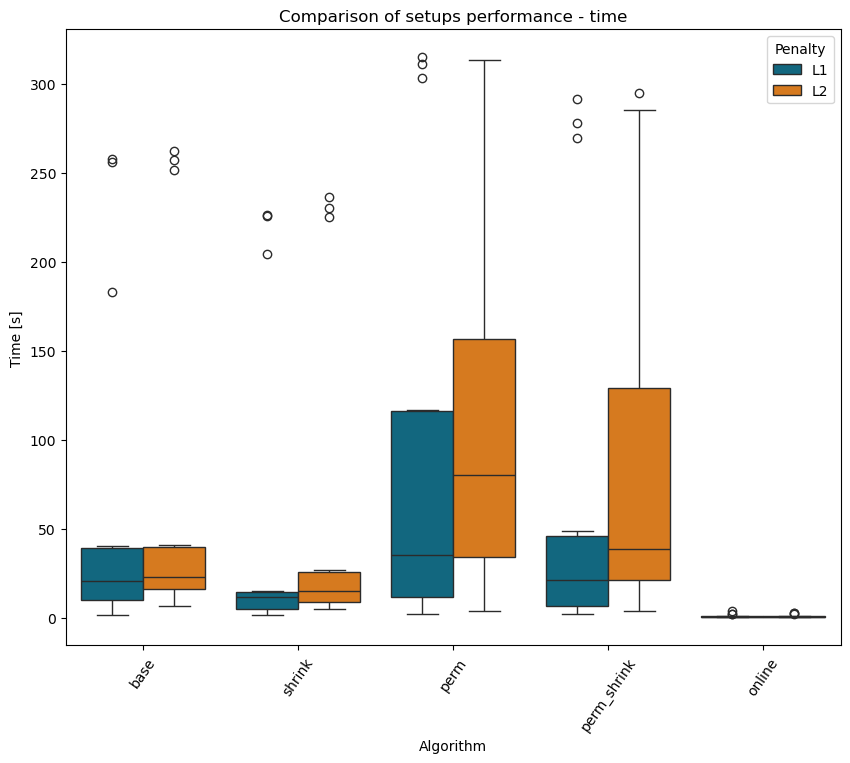

In [10]:
plt.figure(figsize=(10,8))
sns.boxplot(data=phase1_own, x="method", y="time_s", hue="method_type", palette=PENALTY_COLORS)
plt.xticks(rotation=55)
plt.legend(title="Penalty")
plt.xlabel("Algorithm")
plt.ylabel("Time [s]")
plt.title("Comparison of setups performance - time")
plt.show()


## PHASE 2 - Penalty parameter C

In [11]:
phase2["method_type"] = np.where(
    phase2["method"].str.contains("dcd", case=False, na=False),
    "our implementation",
    "sklearn"
)

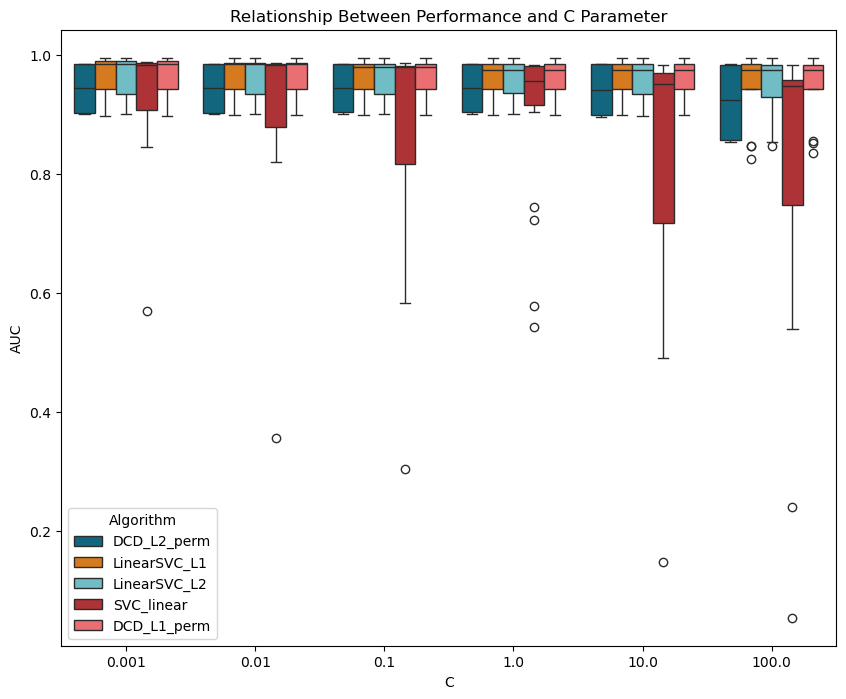

In [12]:
plt.figure(figsize=(10,8))
sns.boxplot(data=phase2, x="C", y="auc", hue="method", palette=METHOD_COLORS)
plt.legend(title="Algorithm", loc="lower left")
plt.xlabel("C")
plt.ylabel("AUC")
plt.title("Relationship Between Performance and C Parameter")
plt.show()


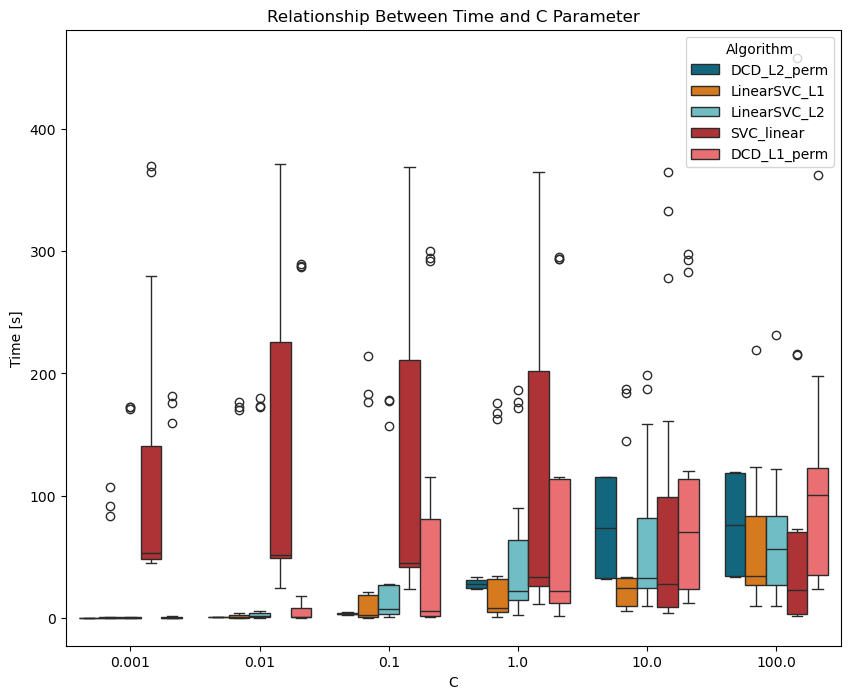

In [13]:
plt.figure(figsize=(10,8))
sns.boxplot(data=phase2, x="C", y="time_s", hue="method", palette=METHOD_COLORS)
plt.legend(title="Algorithm", loc="upper right")
plt.xlabel("C")
plt.ylabel("Time [s]")
plt.title("Relationship Between Time and C Parameter")
plt.show()


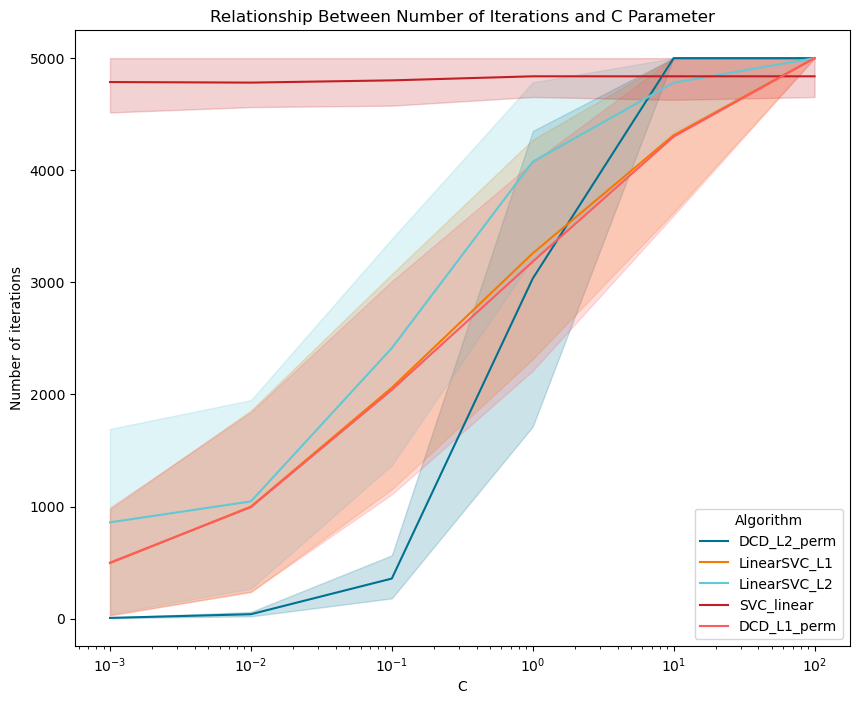

In [14]:
plt.figure(figsize=(10,8))
sns.lineplot(data=phase2, x="C", y="n_iter", hue="method", palette=METHOD_COLORS)
plt.legend(title="Algorithm", loc="lower right")
plt.xlabel("C")
plt.ylabel("Number of iterations")
plt.title("Relationship Between Number of Iterations and C Parameter")
plt.xscale("log")
plt.show()


## PHASE 3 - Scalability analysis

In [15]:
phase3["time_s"] = (
    phase3["time_s"]
    .replace("Timeout >500s", 500)
    .astype(float)
)

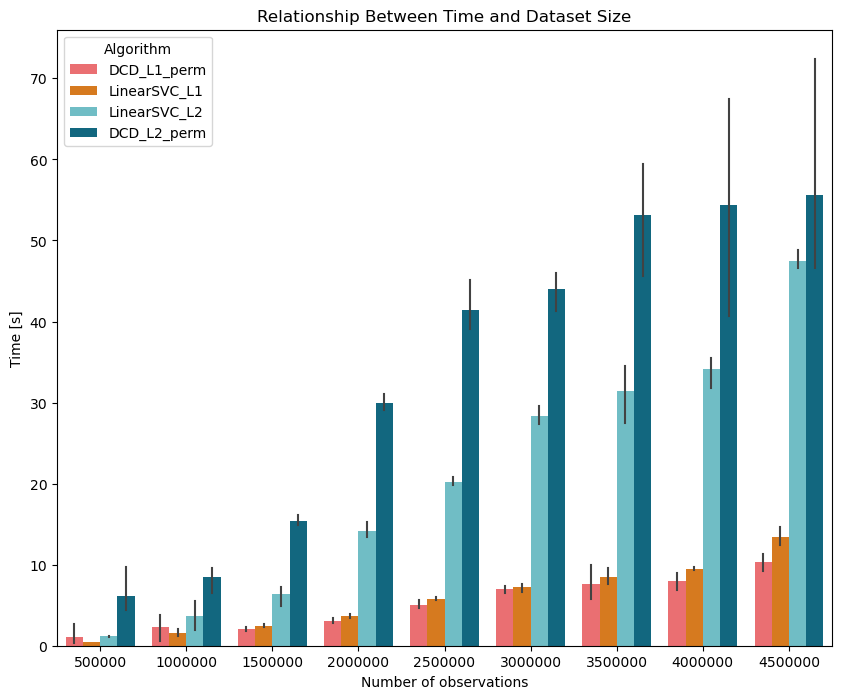

In [16]:
total_rows = sum(1 for line in open("../data/SUSY"))

phase3["n_samples"] = (phase3["fraction"] * total_rows).astype(int)

plot_data = phase3[phase3["method"] != "SVC_linear"]

plt.figure(figsize=(10, 8))
sns.barplot(
    data=plot_data, 
    x="n_samples",     
    y="time_s", 
    hue="method",
    palette=METHOD_COLORS,
    err_kws={"linewidth": 1.5}
)

plt.legend(title="Algorithm", loc="upper left")
plt.xlabel("Number of observations")
plt.ylabel("Time [s]")
plt.title("Relationship Between Time and Dataset Size")

plt.show()


## PHASE 4 - Sparsity impact

In [17]:
phase4["time_s"] = (
    phase4["time_s"]
    .replace(["Timeout >500s", "Skipped (prior timeout)"], 500)
    .astype(float)
)

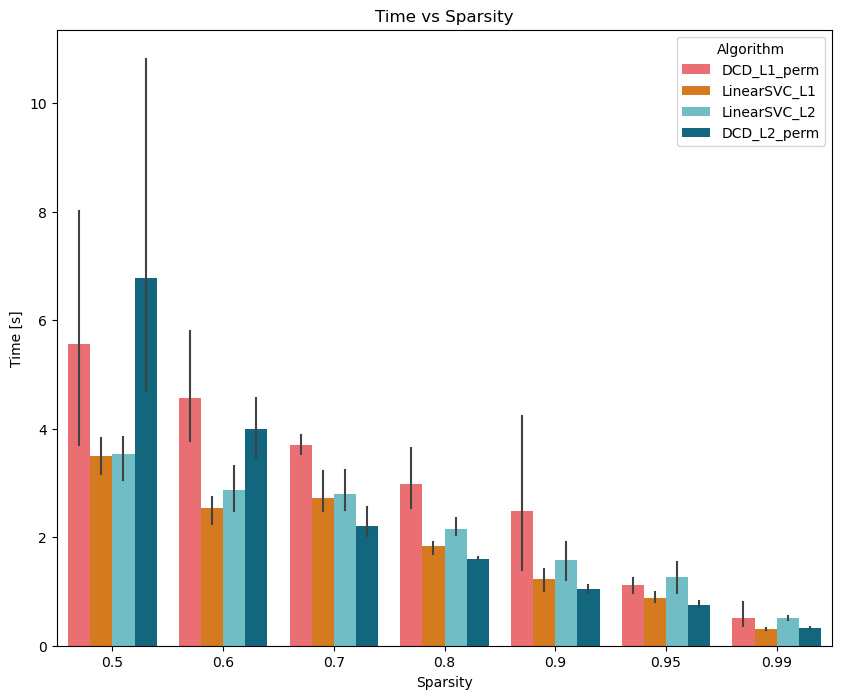

In [18]:
plt.figure(figsize=(10,8))
sns.barplot(data=phase4[phase4["method"] != "SVC_linear"], x="sparsity", y="time_s", hue="method", palette=METHOD_COLORS, err_kws={"linewidth" : 1.5})
plt.legend(title="Algorithm", loc="upper right")
plt.xlabel("Sparsity")
plt.ylabel("Time [s]")
plt.title("Time vs Sparsity")
plt.show()


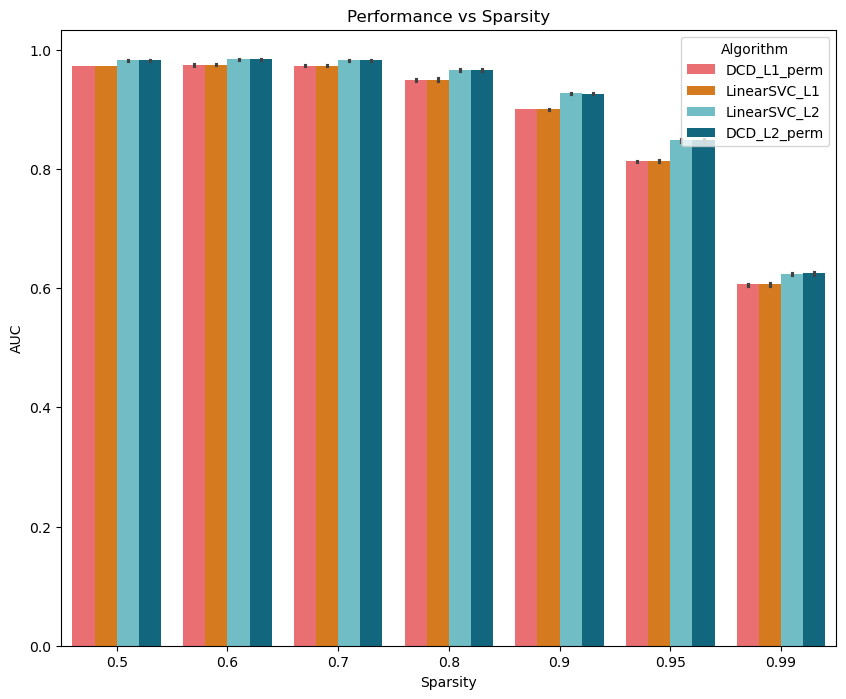

In [19]:
plt.figure(figsize=(10,8))
sns.barplot(data=phase4[phase4["method"] != "SVC_linear"], x="sparsity", y="auc", hue="method", palette=METHOD_COLORS)
plt.legend(title="Algorithm", loc="upper right")
plt.xlabel("Sparsity")
plt.ylabel("AUC")
plt.title("Performance vs Sparsity")
plt.show()


## PHASE 5 - Convergence analysis

In [20]:
from data_loader import load_libsvm

class1_frac = {}
datasets = ["a9a", "cod_rna", "news20", "rcv1", "real-sim", "skin"]

for dataset in datasets:
    data_path = f"../data/{dataset}"
    X, y = load_libsvm(data_path)
    frac = np.sum(y == 1) / len(y)
    class1_frac[dataset] = frac

In [21]:
print(class1_frac)

{'a9a': np.float64(0.23928176569346055), 'cod_rna': np.float64(0.12075207642459461), 'news20': np.float64(0.5000500100020004), 'rcv1': np.float64(0.5182788262029444), 'real-sim': np.float64(0.30754124659447646), 'skin': np.float64(0.2075403173152259)}


In [22]:
df_frac = (
pd.DataFrame.from_dict(
        class1_frac,
        orient="index",
        columns=["frac"]
    )
    .reset_index()
    .rename(columns={"index": "dataset"})
)

phase5 = pd.merge(phase5, df_frac, how="right", on='dataset')

In [23]:
phase5["time_s"] = (
    phase5["time_s"]
    .replace(["Timeout >500s", "Skipped (prior timeout)"], 500)
    .astype(float)
)

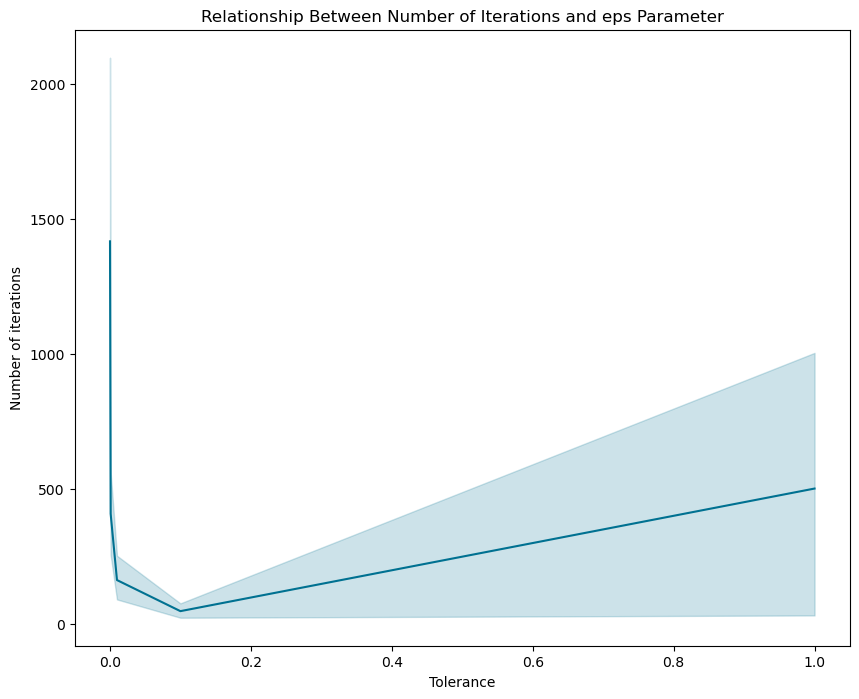

In [24]:
plt.figure(figsize=(10,8))
sns.lineplot(data=phase5, x="tol", y="n_iter")
plt.xlabel("Tolerance")
plt.ylabel("Number of iterations")
plt.title("Relationship Between Number of Iterations and eps Parameter")
plt.show()

## Advanced Visualizations

In [25]:
METHOD_COLORS_EXT = {
    "DCD_L1":             "#ffb0b3",  
    "DCD_L1_shrink":      "#ff8a8e",
    "DCD_L1_perm":        "#ff5a5e", 
    "DCD_L1_perm_shrink": "#d4444a", 
    "DCD_L2":             "#9dd5de", 
    "DCD_L2_shrink":      "#62c8d3",
    "DCD_L2_perm":        "#007191",  
    "DCD_L2_perm_shrink": "#005670", 
    "LinearSVC_L1":       "#f47a00",
    "LinearSVC_L2":       "#fbac2b",
    "SVC_linear":         "#c31e23",
}

MARKERS = {
    "DCD_L1": "^", "DCD_L1_shrink": "p", "DCD_L1_perm": "o", "DCD_L1_perm_shrink": "s",
    "DCD_L2": "<", "DCD_L2_shrink": "h", "DCD_L2_perm": "D", "DCD_L2_perm_shrink": "v",
    "LinearSVC_L1": "P", "LinearSVC_L2": "X", "SVC_linear": "*",
}


### Accuracy vs training time

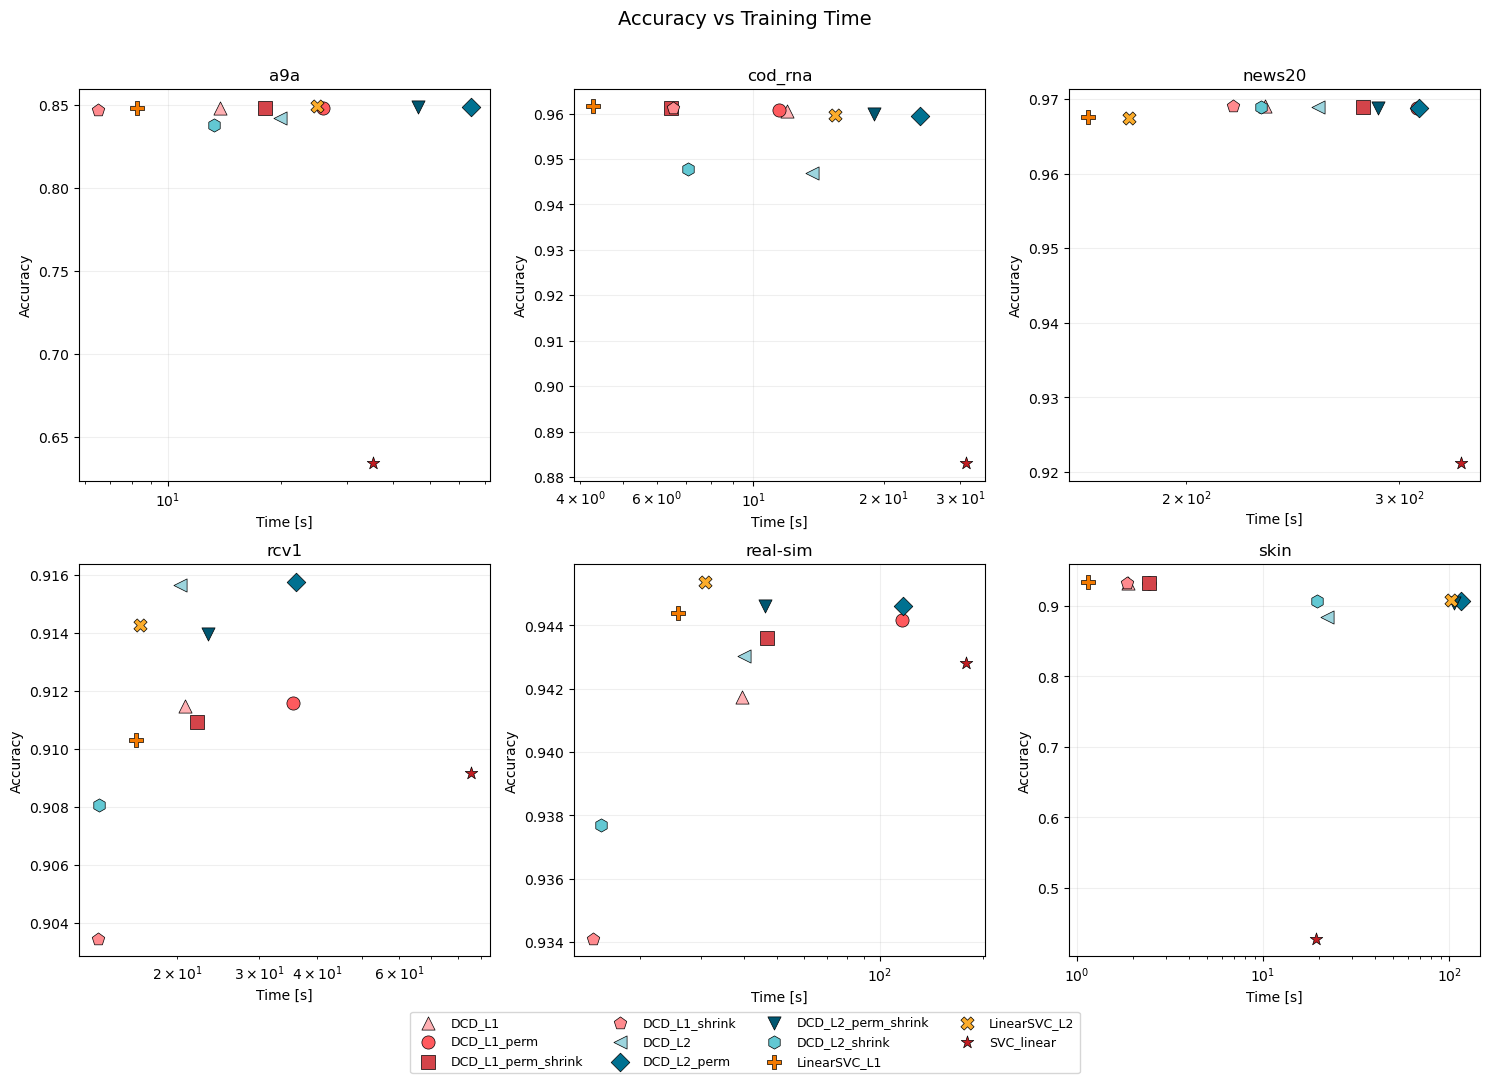

In [31]:
p1_pareto = phase1[~phase1['method'].str.contains('online')].copy()
datasets = sorted(p1_pareto['dataset'].unique())

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, ds in enumerate(datasets):
    ax = axes[idx]
    sub = p1_pareto[p1_pareto['dataset'] == ds]
    agg = sub.groupby('method')[['accuracy', 'time_s']].mean()

    for method, row in agg.iterrows():
        color = METHOD_COLORS_EXT.get(method, 'gray')
        marker = MARKERS.get(method, 'o')
        ax.scatter(row['time_s'], row['accuracy'],
                   c=color, marker=marker, s=90, zorder=3,
                   label=method, edgecolors='black', linewidths=0.5)

    ax.set_title(ds, fontsize=12)
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Accuracy')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.2)

for j in range(len(datasets), len(axes)):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.06), frameon=True, fontsize=9)
fig.suptitle('Accuracy vs Training Time', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()


### Shrinking Speedup Heatmap

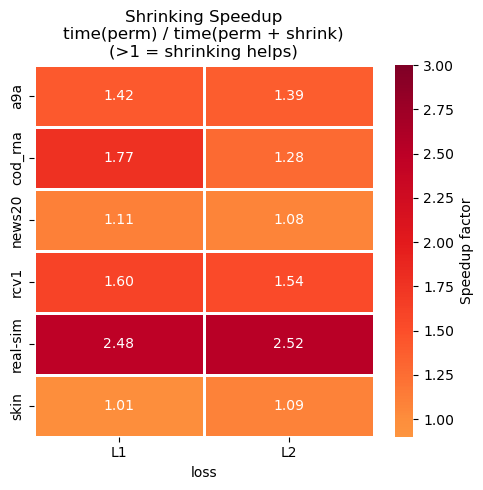

In [27]:
rows = []
for loss in ['L1', 'L2']:
    perm = phase1[phase1['method'] == f'DCD_{loss}_perm'].groupby('dataset')['time_s'].mean()
    shrk = phase1[phase1['method'] == f'DCD_{loss}_perm_shrink'].groupby('dataset')['time_s'].mean()
    for ds in perm.index:
        rows.append({'dataset': ds, 'loss': loss, 'speedup': perm[ds] / shrk[ds]})

pivot = pd.DataFrame(rows).pivot(index='dataset', columns='loss', values='speedup')

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', center=1.0,
            linewidths=1, ax=ax, cbar_kws={'label': 'Speedup factor'},
            vmin=0.9, vmax=3.0)
ax.set_title('Shrinking Speedup\ntime(perm) / time(perm + shrink)\n(>1 = shrinking helps)')
ax.set_ylabel('')
fig.tight_layout()
plt.show()


### Permutation Effect Heatmap

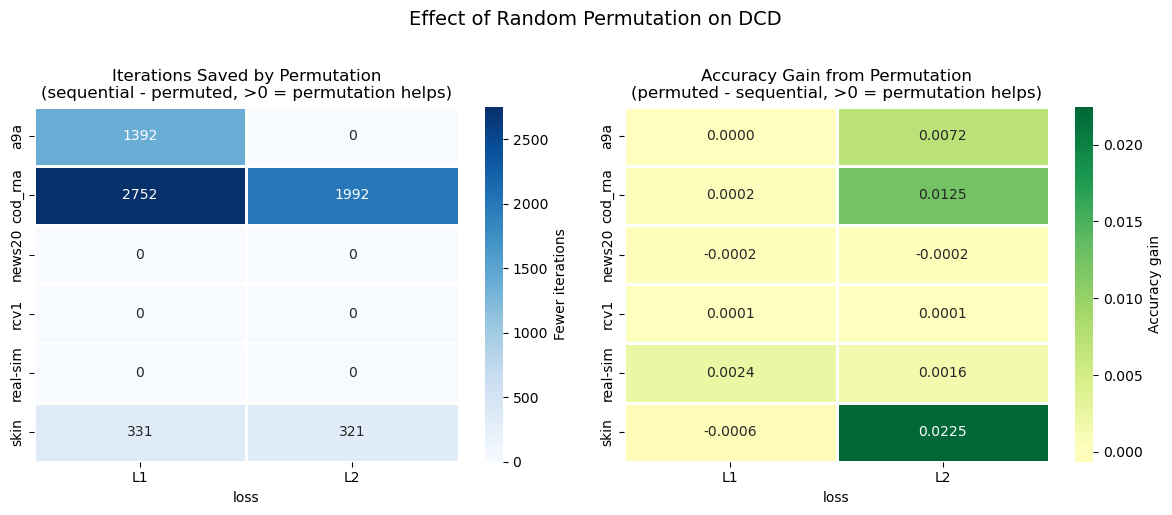

In [28]:
rows = []
for loss in ['L1', 'L2']:
    base = phase1[phase1['method'] == f'DCD_{loss}'].groupby('dataset')[['n_iter', 'accuracy']].mean()
    perm = phase1[phase1['method'] == f'DCD_{loss}_perm'].groupby('dataset')[['n_iter', 'accuracy']].mean()
    for ds in base.index:
        rows.append({
            'dataset': ds, 'loss': loss,
            'iter_saved': base.loc[ds, 'n_iter'] - perm.loc[ds, 'n_iter'],
            'acc_gain': perm.loc[ds, 'accuracy'] - base.loc[ds, 'accuracy'],
        })

df_perm = pd.DataFrame(rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

piv1 = df_perm.pivot(index='dataset', columns='loss', values='iter_saved')
sns.heatmap(piv1, annot=True, fmt='.0f', cmap='Blues', linewidths=1, ax=ax1,
            cbar_kws={'label': 'Fewer iterations'})
ax1.set_title('Iterations Saved by Permutation\n(sequential - permuted, >0 = permutation helps)')
ax1.set_ylabel('')

piv2 = df_perm.pivot(index='dataset', columns='loss', values='acc_gain')
sns.heatmap(piv2, annot=True, fmt='.4f', cmap='RdYlGn', center=0, linewidths=1, ax=ax2,
            cbar_kws={'label': 'Accuracy gain'})
ax2.set_title('Accuracy Gain from Permutation\n(permuted - sequential, >0 = permutation helps)')
ax2.set_ylabel('')

fig.suptitle('Effect of Random Permutation on DCD', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()


### Time Complexity Scaling (SUSY)

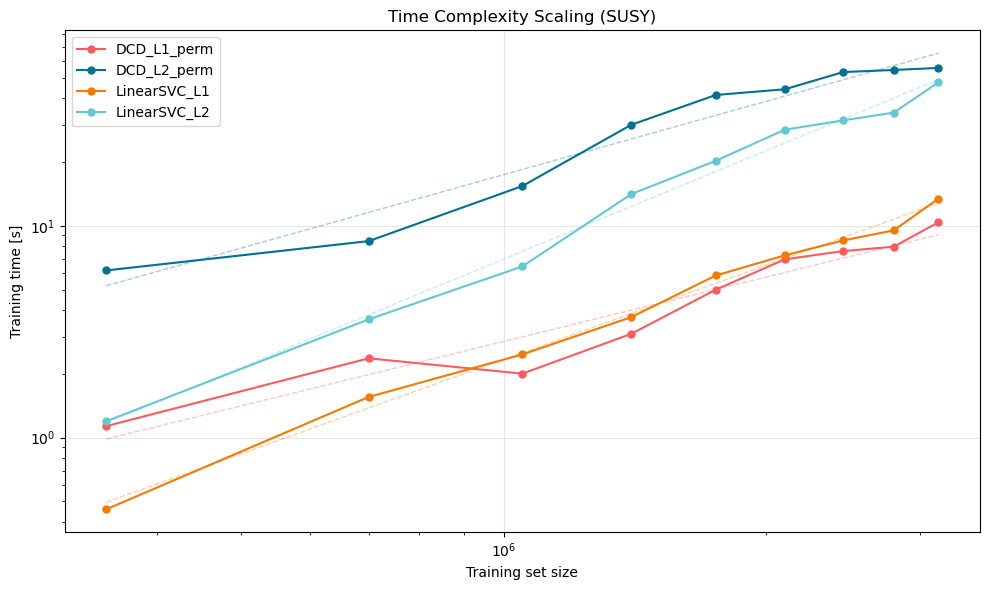

In [30]:
from scipy import stats

p3_scale = phase3.copy()
p3_scale['time_s'] = pd.to_numeric(p3_scale['time_s'], errors='coerce')
p3_scale = p3_scale[p3_scale['time_s'].notna()]
p3_scale['n_train'] = (p3_scale['fraction'] * total_rows * 0.7).astype(int)
p3_scale = p3_scale[p3_scale['method'] != 'SVC_linear']

fig, ax = plt.subplots(figsize=(10, 6))

for method in sorted(p3_scale['method'].unique()):
    sub = p3_scale[p3_scale['method'] == method]
    agg = sub.groupby('n_train')['time_s'].mean().reset_index()
    color = METHOD_COLORS.get(method, METHOD_COLORS_EXT.get(method, 'gray'))

    ax.plot(agg['n_train'], agg['time_s'], 'o-', color=color,
            label=method, markersize=5, linewidth=1.5)

    log_n = np.log10(agg['n_train'].values)
    log_t = np.log10(agg['time_s'].values)
    slope, intercept, *_ = stats.linregress(log_n, log_t)
    ax.plot(agg['n_train'], 10 ** (intercept + slope * log_n),
            '--', color=color, alpha=0.35, linewidth=1)


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Training set size')
ax.set_ylabel('Training time [s]')
ax.set_title('Time Complexity Scaling (SUSY)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
